In [1]:
%load_ext autoreload
%autoreload 2

from src.dynamical_systems import *
from src.SINDyModel import *
from src.derivatives import *
from src.helpers import *

import matplotlib.pyplot as plt
from tqdm import tqdm

In [115]:
def pick_threshold_value(rhs, true_coefficients, x0, dt, t_span, rce_threshold=0.002):
    t_eval = np.arange(t_span[0], t_span[1] + dt, dt)

    # generate ground truth data
    x_train = generate_training_data(rhs, x0, t_eval)

    # generate training data with a very small amount of noise
    x_train_noisy = add_noise_to_data(x_train, noise_level=0.0001)
    x_dot_approx = dxdt_finite_difference(x_train_noisy, t_eval)
    # x_train_noisy = x_train
    # x_dot_approx = rhs(0, x_train)

    n = 100
    thresholds = np.logspace(-5, 0, n)
    results = np.zeros(len(thresholds))

    for i in range(n):
        threshold = thresholds[i]

        model = SINDyModel(n_state_vars=2, threshold=threshold, poly_order=5)
        model.fit(x_train_noisy, x_dot_approx)

        rce = relative_coefficient_error(true_coefficients, model.Xi)

        if rce < rce_threshold:
            results[i] = 1

            print(f"threshold: {threshold:.5f},    did work, relative_coefficient_error: {rce:.5f}")
        else:
            print(f"threshold: {threshold:.5f}, didn't work, relative_coefficient_error: {rce:.5f}")
    
    # check if any viable thresholds were found
    if np.sum(results) == 0:
        print("no viable thresholds found")
        return None

    # get the average viable threshold
    # mean_index = np.rint(np.mean(np.nonzero(results))).astype(int)
    # mean_threshold = thresholds[mean_index]
    mean_threshold = (thresholds[np.max(np.nonzero(results))] + thresholds[np.min(np.nonzero(results))]) / 2

    return mean_threshold


lotka_volterra_rhs = generate_lotka_volterra_rhs(1, 0.1, 1.5, 0.75)
model = SINDyModel(n_state_vars=2, threshold=0.05, poly_order=5)
true_coefficents = generate_lotka_volterra_true_coefficients(1, 0.1, 1.5, 0.75, model)


x0 = (10, 10)
dt = 0.01
t_span = (0, 50)


pick_threshold_value(lotka_volterra_rhs, true_coefficents, x0, dt, t_span, rce_threshold=0.002)

threashold: 0.00001, didn't work, relative_coefficient_error: 0.17171
threashold: 0.00001, didn't work, relative_coefficient_error: 0.17171
threashold: 0.00001, didn't work, relative_coefficient_error: 0.17170
threashold: 0.00001, didn't work, relative_coefficient_error: 0.17171
threashold: 0.00002, didn't work, relative_coefficient_error: 0.17171
threashold: 0.00002, didn't work, relative_coefficient_error: 0.17171
threashold: 0.00002, didn't work, relative_coefficient_error: 0.17171
threashold: 0.00002, didn't work, relative_coefficient_error: 0.17171
threashold: 0.00003, didn't work, relative_coefficient_error: 0.16987
threashold: 0.00003, didn't work, relative_coefficient_error: 0.16986
threashold: 0.00003, didn't work, relative_coefficient_error: 0.16986
threashold: 0.00004, didn't work, relative_coefficient_error: 0.16986
threashold: 0.00004, didn't work, relative_coefficient_error: 0.00346
threashold: 0.00005, didn't work, relative_coefficient_error: 0.00914
threashold: 0.00005,

0.048942034778976004

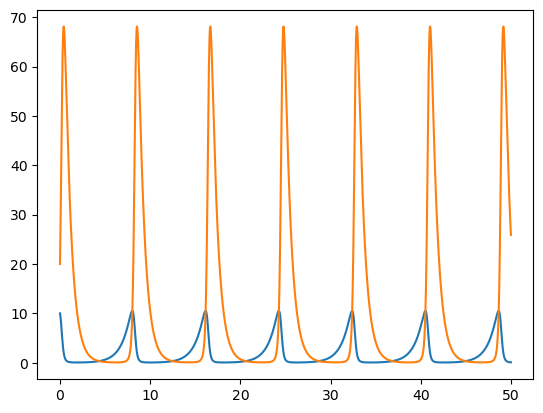

In [112]:
lotka_volterra_rhs = generate_lotka_volterra_rhs(1, 0.1, 1.5, 0.75)


x0 = (10, 20)

dt = 0.01
t_span = (0, 50)
t_eval = np.arange(t_span[0], t_span[1] + dt, dt)

x_train = generate_training_data(lotka_volterra_rhs, x0, t_eval)

plt.plot(t_eval, x_train.T)
plt.show()

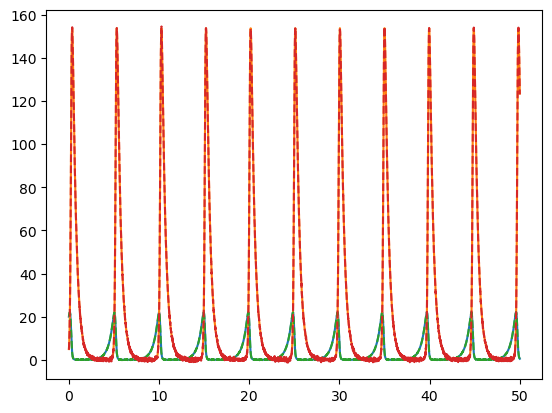

In [60]:
x_train_noisy = add_noise_to_data(x_train, 0.01)

plt.plot(t_eval, x_train.T)
plt.plot(t_eval, x_train_noisy.T, '--')
plt.show()

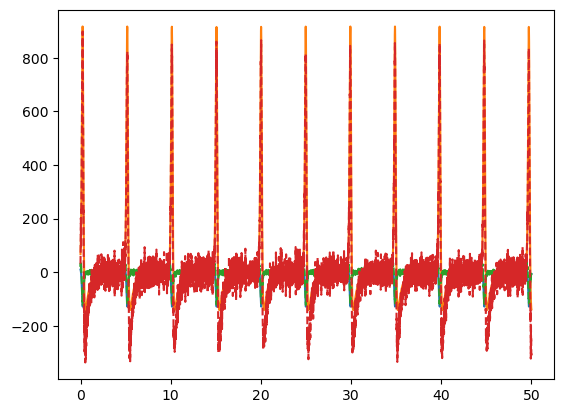

In [61]:
# generate the true derivative
x_dot_true = lotka_volterra_rhs(t_eval, x_train)

x_dot_approx = dxdt_finite_difference(x_train_noisy, t_eval)

plt.plot(t_eval, x_dot_true.T)
plt.plot(t_eval, x_dot_approx.T, '--')
plt.show()